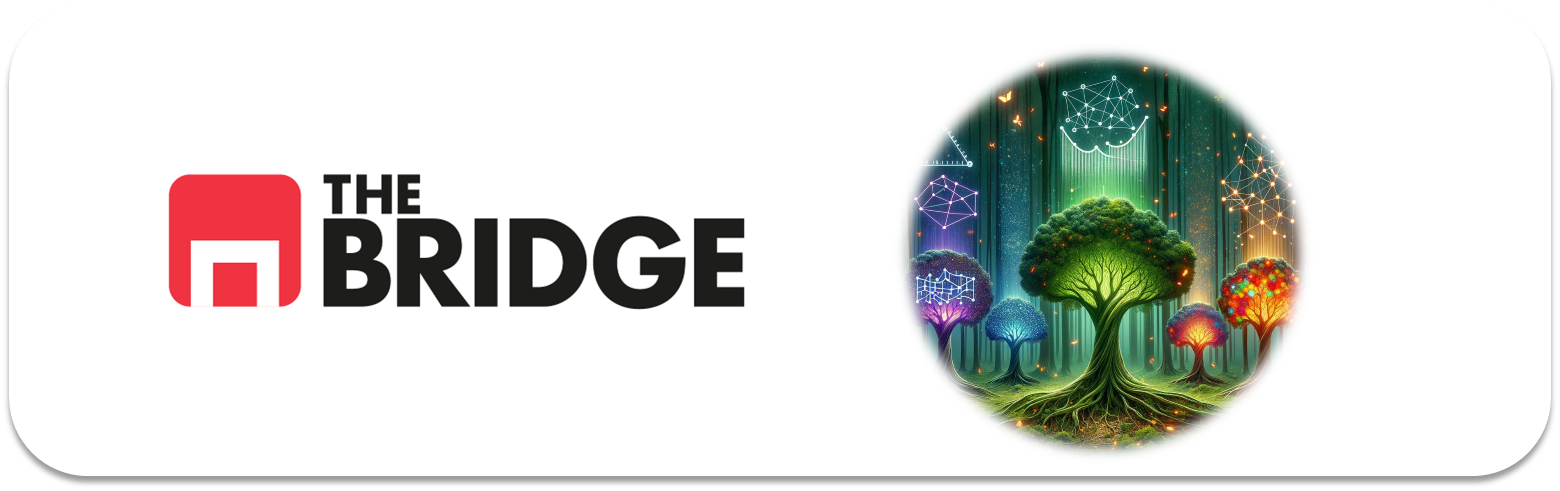

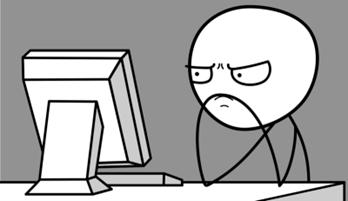

Para ejercitarte y afianzar lo aprendido sobre **Regresion con Árboles de decisión**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

Este conjunto de ejercicios trabajan sobre un dataset de temperaturas tomados de la ciudad de Seattle. El objetivo es intentar predecir lo mejor posible la máxima temperatura (columna `actual`) que alcanzaremos al día siguiente. Para ello contaremos con temperaturas de los dos días anteriores, históricos de máximas temperaturas y un amigo bastante chapas que te da su predicción del tiempo cada día.

**Resumen de datos**:
* year: 2016 for all data points
* month: number for month of the year
* day: number for day of the year
* week: day of the week as a character string
* temp_2: max temperature 2 days prior
* temp_1: max temperature 1 day prior
* average: historical average max temperature
* actual: max temperature measurement
* friend: your friend’s prediction, a random number between 20 below the average and 20 above the average



### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
%matplotlib inline
pd.options.mode.copy_on_write= True

# Pintar!
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)


### Ejercicio 1

Importa el csv "temps.csv"

In [2]:
df = pd.read_csv("./data/temps.csv")
df.head()

,year,month,day,week,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend
0,2016,1,1,Fri,45,45,45.6,45,43,50,44,29
1,2016,1,2,Sat,44,45,45.7,44,41,50,44,61
2,2016,1,3,Sun,45,44,45.8,41,43,46,47,56
3,2016,1,4,Mon,44,41,45.9,40,44,48,46,53
4,2016,1,5,Tues,41,40,46.0,44,46,46,46,41


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            348 non-null    int64  
 1   month           348 non-null    int64  
 2   day             348 non-null    int64  
 3   week            348 non-null    object 
 4   temp_2          348 non-null    int64  
 5   temp_1          348 non-null    int64  
 6   average         348 non-null    float64
 7   actual          348 non-null    int64  
 8   forecast_noaa   348 non-null    int64  
 9   forecast_acc    348 non-null    int64  
 10  forecast_under  348 non-null    int64  
 11  friend          348 non-null    int64  
dtypes: float64(1), int64(10), object(1)
memory usage: 32.8+ KB
None


### Ejercicio 2

Haz un one-hot encoding de las variables categóricas del dataset

In [4]:
# Como "year", "month" y "day" son numéricas, voy a hacer one-hot encoding de "week"
df_copia = df.copy()
df = pd.get_dummies(df["week"])



In [5]:
df.info()

df =pd.concat([df, df_copia])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Fri     348 non-null    bool 
 1   Mon     348 non-null    bool 
 2   Sat     348 non-null    bool 
 3   Sun     348 non-null    bool 
 4   Thurs   348 non-null    bool 
 5   Tues    348 non-null    bool 
 6   Wed     348 non-null    bool 
dtypes: bool(7)
memory usage: 2.5 KB


In [6]:
df = df.drop("week", axis=1)

df.columns

Index(['Fri', 'Mon', 'Sat', 'Sun', 'Thurs', 'Tues', 'Wed', 'year', 'month',
       'day', 'temp_2', 'temp_1', 'average', 'actual', 'forecast_noaa',
       'forecast_acc', 'forecast_under', 'friend'],
      dtype='object')

In [7]:
# Como "year" tiene un valor único lo quito
df = df.drop("year", axis=1)

### Ejercicio 3

Divide en train y test

In [8]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df, test_size = 0.2)

In [9]:
X_train = train_set.drop("actual", axis= 1)
y_train = train_set["actual"]
X_test = test_set.drop("actual", axis= 1)
y_test = test_set["actual"]

In [10]:
X_train.describe()

,month,day,temp_2,temp_1,average,forecast_noaa,forecast_acc,forecast_under,friend
count,278.000000,278.000000,278.000000,278.000000,278.000000,278.000000,278.000000,278.000000,278.000000
mean,6.561151,15.514388,63.136691,63.122302,60.010072,57.535971,62.557554,60.071942,60.158273
std,3.483048,8.648666,12.464072,12.401794,10.653027,10.727868,10.705540,10.844913,15.600962
min,1.000000,1.000000,35.000000,35.000000,45.100000,41.000000,46.000000,44.000000,28.000000
25%,4.000000,8.000000,54.250000,54.000000,49.900000,48.000000,52.000000,50.000000,49.000000
50%,7.000000,15.000000,62.500000,63.000000,58.800000,56.000000,61.000000,59.000000,59.500000
75%,10.000000,23.000000,72.000000,71.750000,69.250000,66.000000,72.000000,69.000000,71.000000
max,12.000000,31.000000,117.000000,117.000000,77.400000,77.000000,82.000000,79.000000,95.000000


NO HE COMPROBADO:  
LA DISTRIBUCIÓN DEL TARGET.  
LOS HISTOGRAMAS, NO HE NORMALIZADO SI HACÍA FALTA Y TAMPOCO HE ESCALADO.  

### Ejercicio 4

Instancia un DecisionTreeRegressor de sklearn con hiperparámetros por defecto y entrénalo.

In [11]:
print(y_train.value_counts(dropna=False, normalize=True))

actual
NaN     0.500000
68.0    0.023381
60.0    0.023381
57.0    0.023381
65.0    0.019784
52.0    0.017986
51.0    0.017986
67.0    0.016187
75.0    0.016187
59.0    0.016187
77.0    0.014388
63.0    0.014388
48.0    0.014388
66.0    0.014388
54.0    0.014388
71.0    0.014388
64.0    0.014388
49.0    0.014388
55.0    0.012590
74.0    0.012590
76.0    0.012590
61.0    0.010791
56.0    0.010791
81.0    0.008993
79.0    0.008993
72.0    0.008993
73.0    0.008993
62.0    0.008993
58.0    0.008993
45.0    0.007194
70.0    0.005396
53.0    0.005396
80.0    0.005396
69.0    0.005396
40.0    0.005396
41.0    0.005396
85.0    0.005396
46.0    0.005396
39.0    0.003597
78.0    0.003597
83.0    0.003597
44.0    0.003597
50.0    0.003597
35.0    0.003597
82.0    0.003597
87.0    0.003597
42.0    0.003597
36.0    0.001799
86.0    0.001799
89.0    0.001799
84.0    0.001799
92.0    0.001799
43.0    0.001799
88.0    0.001799
90.0    0.001799
Name: proportion, dtype: float64


In [12]:
y_train = y_train.fillna(y_train.mean())

In [13]:
y_test = y_test.fillna(y_train.mean())

In [14]:
from sklearn.tree import DecisionTreeRegressor
arbol_cuñao = DecisionTreeRegressor()
arbol_cuñao.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

### Ejercicio 5

Calcula su MAE sin usar sklearn.

Calcular el MAE (Mean Absolute Error):
La fórmula es:    
MAE = (1/n) × Σ|y_true - y_pred|  
Es decir, el promedio de las diferencias absolutas entre los valores reales y las predicciones.  
Errores en unidades del target.  

In [ ]:
y_train_pred = arbol_cuñao.predict(X_train)

# Con numpy
MAE_np = np.mean(np.abs(y_train - y_train_pred))
print("MAE de train (np): ", MAE_np)

# Con pandas
MAE_pd = (y_train - y_train_pred).abs().mean()
print("MAE de train (pd): ", MAE_pd)

# Lo mismo con test
y_test_pred = arbol_cuñao.predict(X_test)
MAE_test_np = np.mean(np.abs(y_test - y_test_pred))
print("MAE de test (np): ", MAE_test_np)
MAE_test_pd = (y_test - y_test_pred).abs().mean()
print("MAE de test (pd): ", MAE_test_pd)

MAE de train (np):  2.1671553440683056e-13
MAE de train (pd):  2.1671553440683056e-13
MAE de test (np):  2.5428571428573594
MAE de test (pd):  2.5428571428573594


In [ ]:
# MAE con PYTHON sin librerias.
MAE = sum(abs(true - pred) for true, pred in zip(y_test, y_test_pred)) / len(y_test)
print(MAE)

2.54285714285736


### Ejercicio 6

Calcula su MAPE sin usar sklearn

Calcular el MAPE (Mean Absolute Percentage Error):  
La fórmula es:    
MAE = (100%/n) × Σ|(y_true - y_pred) / y_true|  
Qué porcentaje de error promedio comete el modelo respecto al valor real.  

In [18]:
# Con numpy
MAPE_np = np.mean(np.abs((y_train - y_train_pred) / y_train) * 100)
print("MAPE de train (np): ", MAPE_np)

MAPE_test_np = np.mean(np.abs((y_test - y_test_pred) / y_test) * 100)
print("MAPE de test (np): ", MAPE_test_np)

MAPE de train (np):  3.447211681930474e-13
MAPE de test (np):  4.318424252321171


MAPE de train casi 0 un ajuste casi perfecto con los datos de entrenamiento, posible sobreajuste del modelo. El contraste entre train (casi 0%) y test (4.32%) sugiere overfitting leve. Tu modelo se ajusta demasiado bien a los datos de entrenamiento pero generaliza razonablemente bien.

### Ejercicio 7

Representa el árbol de decision

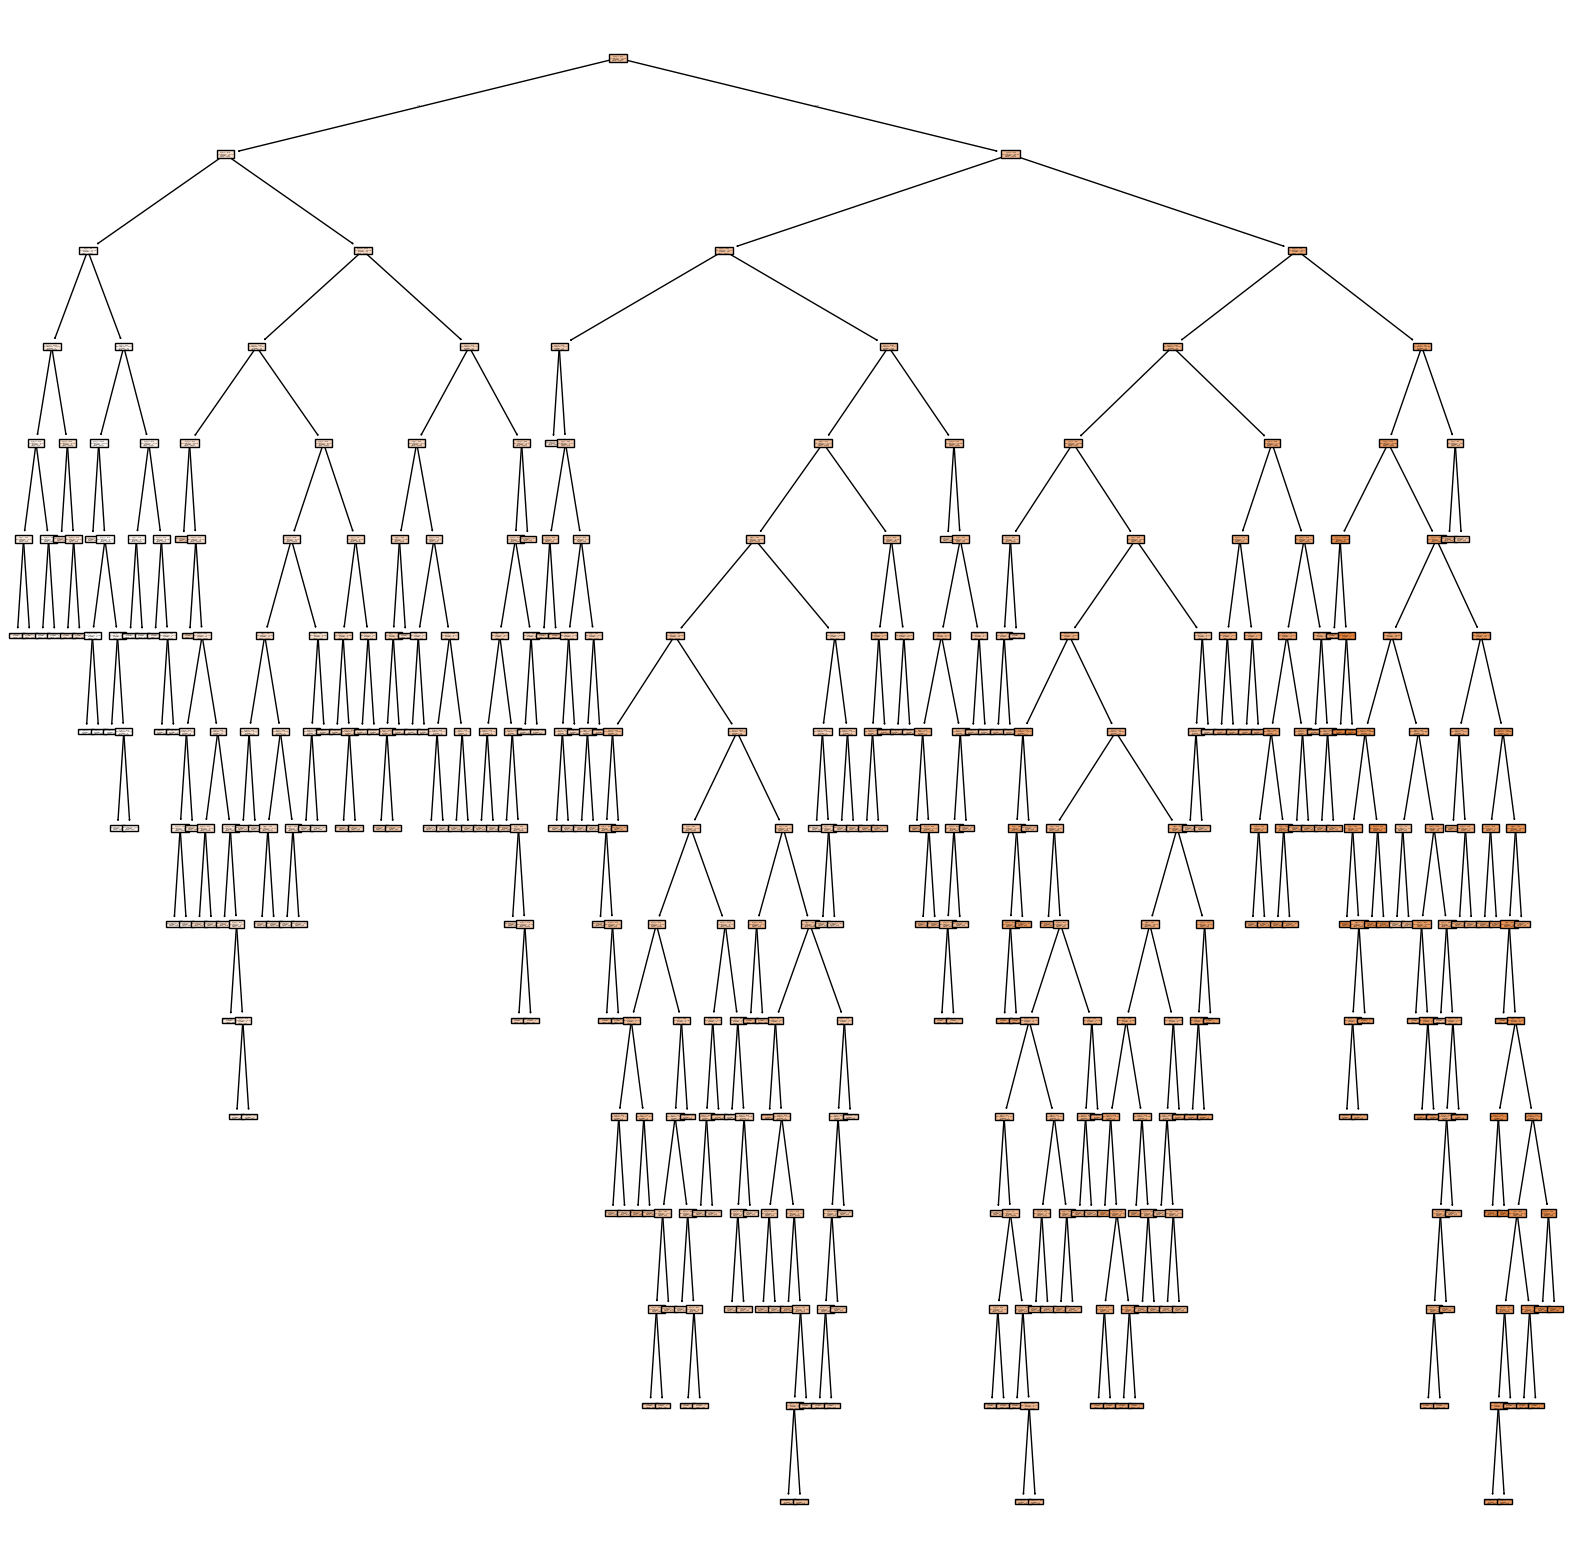

In [19]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,20))
plot_tree(arbol_cuñao, filled=True);

### Ejercicio 8. 

Instancia un nuevo árbol ahora con max_depth a 3 y vuelve a entrenarlo

In [20]:
# Para este entrenamiento un poco más serio, voy a quitar de las features la columna 'friend':
X_train_2 = X_train.drop("friend", axis= 1)
arbol=DecisionTreeRegressor(max_depth= 3)

arbol.fit(X_train_2, y_train)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

In [21]:
X_test_2 = X_test.drop("friend", axis= 1)

### Ejercicio 9

Vuelve a calcular MAE y MAPE

In [22]:
y_train_pred_2 = arbol.predict(X_train_2)
y_test_pred_2 = arbol.predict(X_test_2)

# Con pandas
MAE_train = (y_train - y_train_pred_2).abs().mean()
print("MAE de train (pd): ", MAE_train)
MAE_test = (y_test - y_test_pred_2).abs().mean()
print("MAE de test (pd): ", MAE_test)

MAPE_train = (((y_train - y_train_pred_2) / y_train) * 100).abs().mean()
print("MAPE de train (pd): ", MAPE_train)
MAPE_test = (((y_test - y_test_pred_2) / y_test) * 100).abs().mean()
print("MAPE de test (pd): ", MAPE_test)

MAE de train (pd):  1.9009379862753026
MAE de test (pd):  2.1267612612994387
MAPE de train (pd):  3.011070447117841
MAPE de test (pd):  3.61585188182793


Con max_depth=3, el árbol es más simple y generaliza mejor. El MAPE de test del 3.62% significa que en promedio se equivoca un 3.62% respecto al valor real, lo cual es excelente.
La pequeña diferencia entre train y test (0.6 puntos porcentuales) es totalmente normal y saludable. Siempre esperamos que el modelo funcione ligeramente mejor en train que en test.
Conclusión: Limitando max_depth=3 has conseguido un modelo simple, interpretable y con muy buen rendimiento.

### Ejercicio 10

Vuelve a representar su árbol

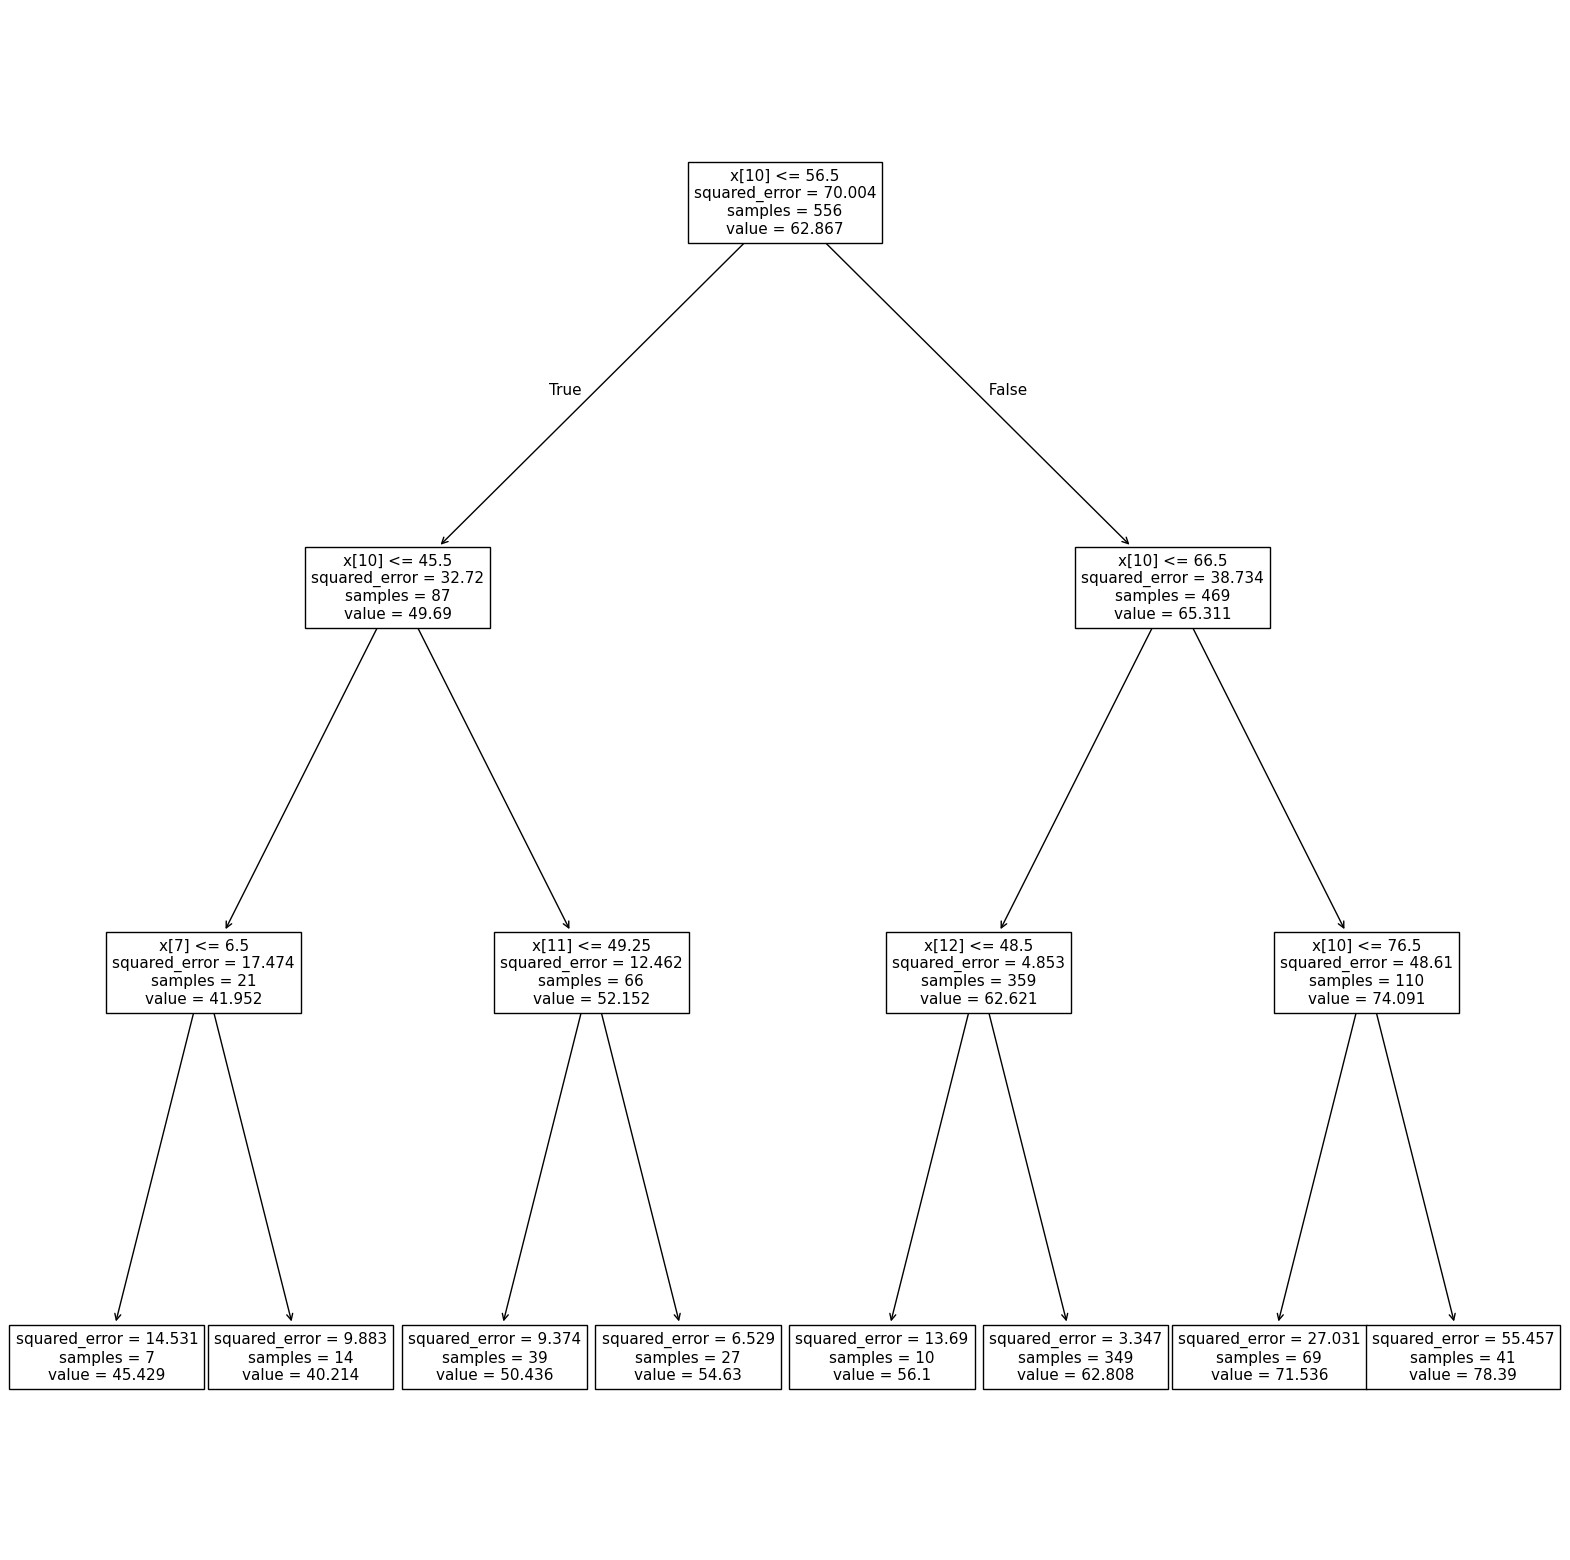

In [25]:
plt.figure(figsize=(20,20))
plot_tree(arbol, filled=False);

### Ejercicio 11

Obten el `feature_importances` de cada variable en el último modelo. Los árboles una vez entrenados tienen un atributo que te lo permite, revisa la documentación si es necesario.

Atributo feature_importances_ : array of shape = [n_features]  

The feature importances. The higher, the more important the feature. The importance of a feature is computed as the (normalized) total reduction of the criterion brought by that feature. It is also known as the Gini importance.

In [26]:
arbol.feature_importances_

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.0038806 , 0.        , 0.        ,
       0.97415846, 0.00858199, 0.01337896, 0.        , 0.        ])

In [27]:
X_train_2.columns

Index(['Fri', 'Mon', 'Sat', 'Sun', 'Thurs', 'Tues', 'Wed', 'month', 'day',
       'temp_2', 'temp_1', 'average', 'forecast_noaa', 'forecast_acc',
       'forecast_under'],
      dtype='object')

In [31]:
print(arbol.max_features_)

15
